# Vision Transformer (ViT-Tiny) - Multi-Task Learning - 9996 Samples

This notebook trains a Vision Transformer (ViT-Tiny) model with **Multi-Task Learning** architecture for forgery detection on driver's licenses.

**Model Architecture:** ViT-Tiny with Two-Head (Binary + Fraud Type)
- **Backbone**: ViT-Tiny (shared features, pretrained on ImageNet)
- **Head 1**: Binary Classifier (Real=0, Fake=1) - 2 classes
- **Head 2**: Fraud Type Classifier (Morphing=0, Replacement=1) - 2 classes, only on fakes

**Dataset Size:** 9996 images (balanced 50/50 Real/Fake, balanced across 3 countries: WV, DC, AZ)

**Training Configuration:**
- Batch size: 128
- Learning Rate: 8e-5
- Weight decay: 0.05
- Dropout: 0.2
- Loss: Combined (Binary Loss + 0.5 * Fraud Type Loss)

**Multi-Task Learning Approach:**
- ✅ **Two-Head Architecture**: Shared backbone learns features for both tasks
- ✅ **Conditional Loss**: Fraud type loss calculated only on fake images
- ✅ **Dual Evaluation**: Separate metrics for binary classification and fraud type classification
- ✅ **Aggressive Albumentations**: Simulates real-world conditions
- ✅ **Data Leakage Prevention**: Subject-based split using `original_id`
- Best model checkpoint saving based on combined validation performance


## Setup and Data Loading

Set working directory and load the multi-task dataset CSV file. Split into train/validation/test sets using GroupShuffleSplit with `original_id` to prevent data leakage (ensuring same person's images stay in same split).


In [1]:
import os
import sys

# Fix working directory issue - ensure we're in the project root
project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Warning: Project root {project_root} does not exist!")
    print(f"Current directory: {os.getcwd()}")

# Verify directory exists
if not os.path.exists(os.getcwd()):
    # Create it if it doesn't exist
    os.makedirs(os.getcwd(), exist_ok=True)
    print(f"Created directory: {os.getcwd()}")


Changed working directory to: /Users/roy-siftt/final-project


In [2]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import os

# Load the multi-task dataset
DATASET_CSV = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/data/dataset.csv"
df = pd.read_csv(DATASET_CSV)

print(f"Dataset loaded: {len(df)} images")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nBinary distribution (is_fake):")
print(df['is_fake'].value_counts().sort_index())
print(f"\nFraud type distribution (on fakes only):")
print(df[df['is_fake'] == 1]['fraud_type'].value_counts())
print(f"\nCountry distribution:")
print(df['source_country'].value_counts())

# Use original_id for grouping to prevent data leakage
print(f"\nUnique subjects (original_id): {df['original_id'].nunique()}")

# Split 1: Train and (Test+Val) - 80% train, 20% test+val
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(splitter.split(df, groups=df['original_id']))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# Split 2: Val and Test - 50% each of the 20% (10% each of total)
splitter2 = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['original_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"\nFinal split sizes:")
print(f"  Train: {len(train_df)} images")
print(f"  Val:   {len(val_df)} images")
print(f"  Test:  {len(test_df)} images")

# Verify no leakage
train_ids = set(train_df['original_id'])
val_ids = set(val_df['original_id'])
test_ids = set(test_df['original_id'])

print(f"\nData Leakage Check:")
print(f"  Train-Val overlap: {len(train_ids & val_ids)} subjects")
print(f"  Train-Test overlap: {len(train_ids & test_ids)} subjects")
print(f"  Val-Test overlap: {len(val_ids & test_ids)} subjects")

if len(train_ids & val_ids) == 0 and len(train_ids & test_ids) == 0 and len(val_ids & test_ids) == 0:
    print("  ✅ No data leakage detected!")
else:
    print("  ⚠️  WARNING: Data leakage detected!")


Dataset loaded: 9996 images

Dataset columns: ['image_path', 'label', 'label_name', 'is_fake', 'fraud_type', 'original_id', 'source_country', 'original_filename']

Binary distribution (is_fake):
is_fake
0    4998
1    4998
Name: count, dtype: int64

Fraud type distribution (on fakes only):
fraud_type
face_morphing       2499
face_replacement    2499
Name: count, dtype: int64

Country distribution:
source_country
WV    3332
DC    3332
AZ    3332
Name: count, dtype: int64

Unique subjects (original_id): 4998

Final split sizes:
  Train: 7996 images
  Val:   1000 images
  Test:  1000 images

Data Leakage Check:
  Train-Val overlap: 0 subjects
  Train-Test overlap: 0 subjects
  Val-Test overlap: 0 subjects
  ✅ No data leakage detected!


In [3]:
# Save splits to CSV files
data_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/data"
os.makedirs(data_dir, exist_ok=True)

train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "val.csv")
test_path = os.path.join(data_dir, "test.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"✓ Train saved to: {train_path}")
print(f"✓ Val saved to: {val_path}")
print(f"✓ Test saved to: {test_path}")

print(f"\n{'='*60}")
print(f"Split Summary:")
print(f"{'='*60}")
print(f"\nTrain Set: {len(train_df)} images")
print(f"  Binary: {train_df['is_fake'].value_counts().to_dict()}")
print(f"  Fraud Type (fakes only): {train_df[train_df['is_fake']==1]['fraud_type'].value_counts().to_dict()}")

print(f"\nValidation Set: {len(val_df)} images")
print(f"  Binary: {val_df['is_fake'].value_counts().to_dict()}")
print(f"  Fraud Type (fakes only): {val_df[val_df['is_fake']==1]['fraud_type'].value_counts().to_dict()}")

print(f"\nTest Set: {len(test_df)} images")
print(f"  Binary: {test_df['is_fake'].value_counts().to_dict()}")
print(f"  Fraud Type (fakes only): {test_df[test_df['is_fake']==1]['fraud_type'].value_counts().to_dict()}")
print(f"{'='*60}")


✓ Train saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/data/train.csv
✓ Val saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/data/val.csv
✓ Test saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/data/test.csv

Split Summary:

Train Set: 7996 images
  Binary: {0: 3998, 1: 3998}
  Fraud Type (fakes only): {'face_replacement': 2005, 'face_morphing': 1993}

Validation Set: 1000 images
  Binary: {0: 500, 1: 500}
  Fraud Type (fakes only): {'face_morphing': 256, 'face_replacement': 244}

Test Set: 1000 images
  Binary: {0: 500, 1: 500}
  Fraud Type (fakes only): {'face_morphing': 250, 'face_replacement': 250}


## Custom Multi-Task Dataset Class

Define a PyTorch Dataset class that loads images and returns both labels:
- `is_fake`: Binary label (0=Real, 1=Fake)
- `fraud_type`: Fraud type label (0=Morphing, 1=Replacement) - only valid for Fake images, use -1 for Real images


In [4]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
import cv2

class MultiTaskForgeryDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform
        
        # Fraud type mapping (only for fake images)
        self.fraud_type_map = {
            'face_morphing': 0,
            'face_replacement': 1
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        
        # Apply transforms (Albumentations format)
        if self.transform is not None:
            if hasattr(self.transform, '__call__'):
                try:
                    # Albumentations format (expects numpy array)
                    img_np = np.array(img)
                    transformed = self.transform(image=img_np)
                    img = transformed['image']
                except (TypeError, KeyError):
                    # Fallback to torchvision format (expects PIL Image)
                    img = self.transform(img)
            else:
                img = self.transform(img)

        # Get binary label (is_fake)
        is_fake = int(row['is_fake'])
        
        # Get fraud type label (only for fake images)
        if is_fake == 1:
            fraud_type_str = row['fraud_type']
            fraud_type = self.fraud_type_map.get(fraud_type_str, -1)
            if fraud_type == -1:
                raise ValueError(f"Invalid fraud_type: {fraud_type_str}")
        else:
            # Real images: use -1 as placeholder (will be masked in loss)
            fraud_type = -1

        return img, torch.tensor(is_fake, dtype=torch.long), torch.tensor(fraud_type, dtype=torch.long)


## Data Augmentation and Transforms (IMPROVED - Enhanced for Better Generalization)

Define **enhanced** image transformations using Albumentations to improve generalization and reduce overfitting:
- **Perspective Transforms**: Simulate non-straight camera angles
- **Blur & Noise**: Simulate poor focus and lighting conditions
- **Brightness & Contrast**: Simulate different lighting
- **CoarseDropout**: Random patches removal - forces model to not rely on single regions
- **ShiftScaleRotate**: Geometric distortions
- **ColorJitter**: Color variations

Validation/test use clean transforms without augmentations.


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ============================================
# IMPROVED AUGMENTATIONS - Albumentations (Enhanced for better generalization)
# Stronger augmentation to reduce overfitting and improve test performance
# ============================================
train_transform = A.Compose([
    A.Resize(224, 224),
    
    # Geometric transforms - simulates non-straight camera angles
    A.ShiftScaleRotate(
        shift_limit=0.08,   # Balanced
        scale_limit=0.12,   # Balanced
        rotate_limit=15,
        p=0.6  # Balanced probability
    ),
    A.Perspective(
        scale=(0.05, 0.1),  # Increased for more variation
        p=0.3
    ),
    
    # Quality degradation - simulates poor camera/lighting
    A.GaussianBlur(
        blur_limit=(3, 7),  # Increased range
        p=0.3  # Increased probability
    ),
    A.GaussNoise(
        std_range=(0.04, 0.12),  # Reduced noise for better balance (as fraction of 255)
        mean_range=(0.0, 0.0),
        p=0.2  # Reduced probability
    ),
    A.ColorJitter(
        brightness=0.15,  # Balanced
        contrast=0.15,    # Balanced
        saturation=0.15,  # Balanced
        hue=0.05,         # Balanced
        p=0.4  # Balanced probability
    ),
    
    # CoarseDropout - added back to prevent overfitting to specific regions
    A.CoarseDropout(
        num_holes_range=(1, 6),      # Reduced number of holes
        hole_height_range=(4, 12),    # Reduced height in pixels
        hole_width_range=(4, 12),     # Reduced width in pixels
        fill_value=0,
        p=0.2  # Reduced probability
    ),
    
    # Normalization and tensor conversion
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

# Clean validation/test transforms without augmentations
val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

print("✓ Balanced augmentations configured (Albumentations):")
print("  - ShiftScaleRotate: shift=8%, scale=12%, rotate=15° (60% prob) - BALANCED")
print("  - Perspective: scale=5-10% (30% prob)")
print("  - GaussianBlur: blur_limit=3-7 (30% prob)")
print("  - GaussNoise: std_range=0.04-0.12 (20% prob) - BALANCED")
print("  - ColorJitter: brightness/contrast/saturation/hue (40% prob) - BALANCED")
print("  - CoarseDropout: 1-6 holes, size=4-12px (20% prob) - BALANCED")
print("  → Balanced augmentation to reduce overfitting while maintaining learning capability")


✓ Balanced augmentations configured (Albumentations):
  - ShiftScaleRotate: shift=8%, scale=12%, rotate=15° (60% prob) - BALANCED
  - Perspective: scale=5-10% (30% prob)
  - GaussianBlur: blur_limit=3-7 (30% prob)
  - GaussNoise: std_range=0.04-0.12 (20% prob) - BALANCED
  - ColorJitter: brightness/contrast/saturation/hue (40% prob) - BALANCED
  - CoarseDropout: 1-6 holes, size=4-12px (20% prob) - BALANCED
  → Balanced augmentation to reduce overfitting while maintaining learning capability


/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_73020/4119918182.py:42: UserWarning: Argument(s) 'fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [6]:
from torch.utils.data import DataLoader
import os

# Base directory for the dataset
base_dir = "/Users/roy-siftt/final-project"
# Dataset is in the vit folder - images are in notebooks/drivers_license_forgery/vit/images/
dataset_root = os.path.join(base_dir, "notebooks/drivers_license_forgery/vit")
data_dir = os.path.join(base_dir, "notebooks/drivers_license_forgery/vit/data")

# Load datasets with correct paths
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Update image paths to be absolute paths (image_path in CSV is relative to dataset_root)
train_df['image_path'] = train_df['image_path'].apply(lambda x: x)  # Keep relative path, dataset class will join
val_df['image_path'] = val_df['image_path'].apply(lambda x: x)
test_df['image_path'] = test_df['image_path'].apply(lambda x: x)

# Create datasets with different transforms for train and val/test
train_dataset = MultiTaskForgeryDataset(train_df, dataset_root, train_transform)
val_dataset = MultiTaskForgeryDataset(val_df, dataset_root, val_test_transform)
test_dataset = MultiTaskForgeryDataset(test_df, dataset_root, val_test_transform)

# Note: num_workers=0 to avoid pickling issues in Jupyter notebooks
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

print(f"Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")


Dataset sizes:
   Train: 7996
   Val:   1000
   Test:  1000


## Visualize Augmented Batch

Display a sample batch of images after applying aggressive augmentations to see how the model will see the data during training.


Visualizing Augmented Training Batch


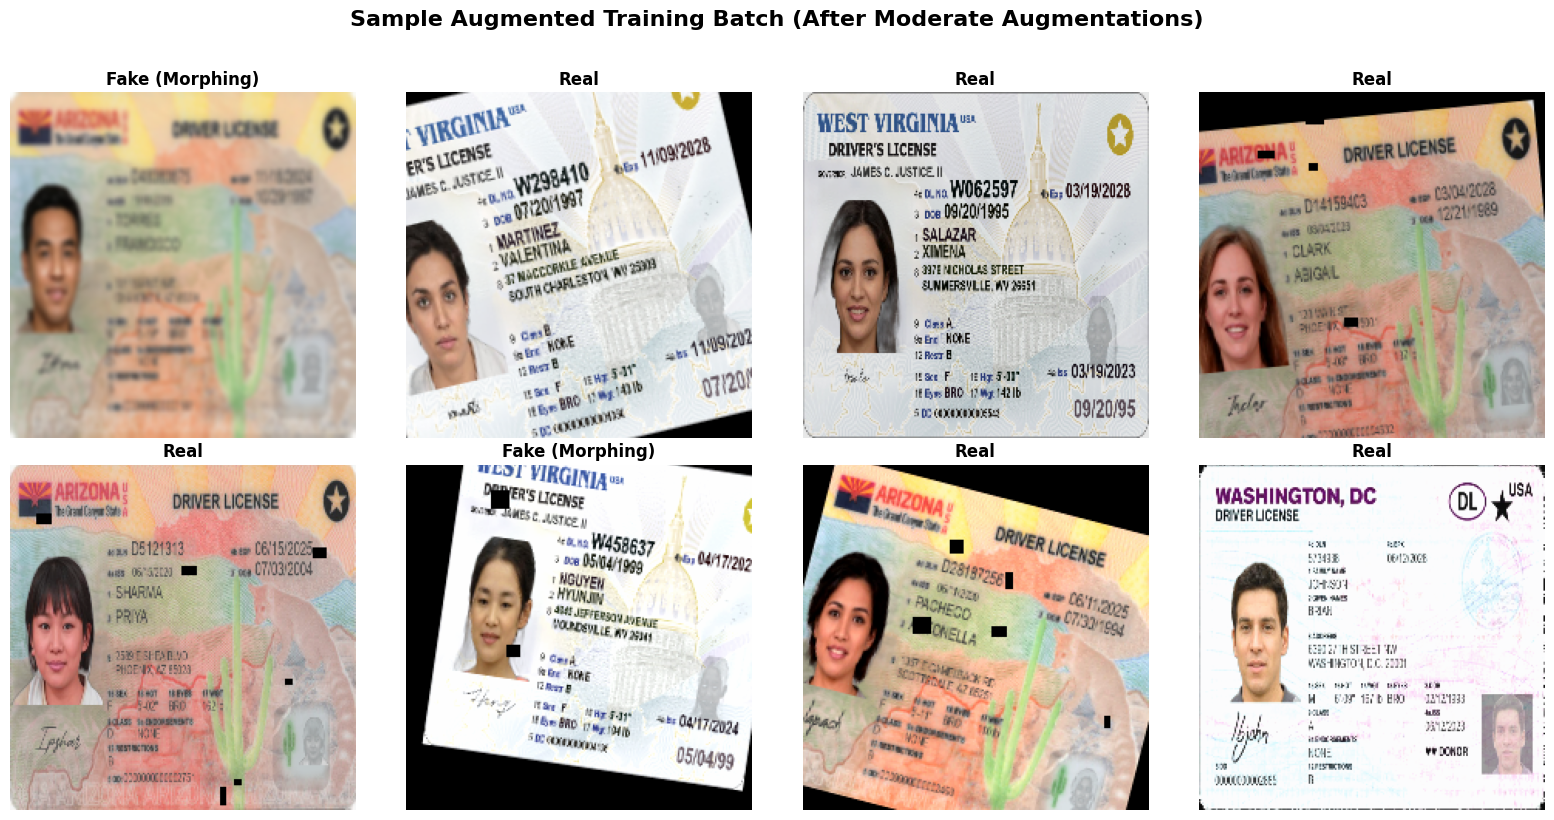

✓ Displayed 8 augmented images from training batch
  Note: Images show effects of Perspective, Blur, ColorJitter (reduced intensity)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_augmented_batch(loader, num_samples=8):
    """
    Display a batch of augmented images from the training loader.
    """
    # Get a batch
    imgs, is_fake_labels, fraud_type_labels = next(iter(loader))
    
    # Limit to num_samples
    imgs = imgs[:num_samples]
    is_fake_labels = is_fake_labels[:num_samples]
    fraud_type_labels = fraud_type_labels[:num_samples]
    
    # Convert tensors to numpy for display
    # Albumentations returns tensors, so we need to denormalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Create grid
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx in range(min(num_samples, len(imgs))):
        img = imgs[idx]
        
        # Convert tensor to numpy and denormalize
        if isinstance(img, torch.Tensor):
            img_np = img.permute(1, 2, 0).cpu().numpy()
            img_np = img_np * std + mean
            img_np = np.clip(img_np, 0, 1)
        else:
            img_np = img
        
        axes[idx].imshow(img_np)
        
        # Create title with both labels
        is_fake = is_fake_labels[idx].item()
        fraud_type = fraud_type_labels[idx].item()
        
        if is_fake == 0:
            title = 'Real'
        else:
            fraud_name = 'Morphing' if fraud_type == 0 else 'Replacement'
            title = f'Fake ({fraud_name})'
        
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(num_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Sample Augmented Training Batch (After Moderate Augmentations)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Displayed {min(num_samples, len(imgs))} augmented images from training batch")
    print(f"  Note: Images show effects of Perspective, Blur, ColorJitter (reduced intensity)")

# Show augmented batch
print("="*60)
print("Visualizing Augmented Training Batch")
print("="*60)
show_augmented_batch(train_loader, num_samples=8)


## ViT-Tiny Multi-Task Model Definition

Define the ViT-Tiny model with **Two-Head** architecture:
- **Backbone**: ViT-Tiny (shared features, pretrained on ImageNet)
- **Head 1**: Binary Classifier (Real vs Fake) - 2 classes
- **Head 2**: Fraud Type Classifier (Morphing vs Replacement) - 2 classes

**Methods:**
- `freeze_backbone()`: Freeze all ViT parameters, train only classifier heads
- `unfreeze_backbone()`: Unfreeze all parameters for full fine-tuning


In [8]:
# Install timm library for Vision Transformer models
%pip install -q timm



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import torch
import torch.nn as nn
import timm

class ViTMultiTaskClassifier(nn.Module):
    def __init__(self, num_binary_classes=2, num_fraud_classes=2, pretrained=True, dropout=0.25):
        super(ViTMultiTaskClassifier, self).__init__()
        
        # Load ViT-Tiny from timm with ImageNet pre-trained weights
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=pretrained, num_classes=0)
        
        # Get the feature dimension (embed_dim for ViT models)
        # For ViT-Tiny, embed_dim is 192
        num_features = self.vit.embed_dim
        
        # Head 1: Binary Classifier (Real vs Fake)
        self.binary_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_binary_classes)
        )
        
        # Head 2: Fraud Type Classifier (Morphing vs Replacement)
        self.fraud_type_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_fraud_classes)
        )
        
        print(f"✓ ViT-Tiny Multi-Task model created (pretrained={pretrained})")
        print(f"  - Feature dimension: {num_features}")
        print(f"  - Dropout: {dropout}")
        print(f"  - Binary head: {num_binary_classes} classes (Real, Fake)")
        print(f"  - Fraud type head: {num_fraud_classes} classes (Morphing, Replacement)")
        
    def forward(self, x):
        # Get features from ViT backbone
        features = self.vit(x)
        
        # Pass through both heads
        binary_output = self.binary_head(features)
        fraud_type_output = self.fraud_type_head(features)
        
        return binary_output, fraud_type_output
    
    def freeze_backbone(self):
        """Freeze all parameters except the classifier heads"""
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.binary_head.parameters():
            param.requires_grad = True
        for param in self.fraud_type_head.parameters():
            param.requires_grad = True
        print("✓ Backbone frozen - training only classifier heads")
    
    def unfreeze_backbone(self):
        """Unfreeze all parameters for full fine-tuning"""
        for param in self.parameters():
            param.requires_grad = True
        print("✓ Backbone unfrozen - full fine-tuning enabled")


## Training Setup and Execution

**Training Configuration:**
- Freeze backbone: `model.freeze_backbone()` (remains frozen throughout)
- **Epochs: 15**
- Optimizer: AdamW, **lr: 1e-4 (Stage 1) / 1e-5 (Stage 2)**, weight_decay=0.075
- Learning Rate Scheduler: ReduceLROnPlateau (factor=0.5, patience=3-4, min_lr=1e-7)
- Early Stopping: patience=6
- **Loss Function**: Combined loss = Binary Loss + 1.0 * Fraud Type Loss
  - Binary loss calculated on all images
  - Fraud type loss calculated only on fake images (masked for Real images)

**Training Settings (BALANCED for optimal generalization):**
- Gradient Clipping: max_norm=1.0
- Label Smoothing: 0.075 (balanced - increased from 0.05)
- Dropout: 0.25 (balanced - increased from 0.2)
- Weight Decay: 0.075 (balanced - increased from 0.05)
- **Balanced Augmentation**: GaussNoise and CoarseDropout with reduced intensity

**Model Checkpointing:**
- Save best model based on combined validation metric (binary accuracy + fraud type accuracy)


In [10]:
import torch
from torch.optim import AdamW
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

# ============================================
# Model Setup - ViT-Tiny Multi-Task
# ============================================
model = ViTMultiTaskClassifier(num_binary_classes=2, num_fraud_classes=2, pretrained=True, dropout=0.25).to(device)

# Loss functions
binary_criterion = nn.CrossEntropyLoss(label_smoothing=0.075)
fraud_type_criterion = nn.CrossEntropyLoss(label_smoothing=0.075)

# Loss weight for fraud type task (increased for better balance)
FRAUD_TYPE_WEIGHT = 1.0

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_binary_acc': [], 'val_binary_acc': [],
    'train_fraud_acc': [], 'val_fraud_acc': [],
    'train_combined_acc': [], 'val_combined_acc': [],
    'lr': []
}

# Best model tracking
best_val_combined_acc = 0.0
best_model_state = None
best_epoch = 0

# Settings
max_grad_norm = 1.0
early_stopping_patience = 6  # Increased for two-stage training
min_delta = 0.005  # Reduced for more sensitive improvement detection

def evaluate(loader):
    """Evaluate model on a dataset loader - returns metrics for both tasks"""
    model.eval()
    
    # Binary task metrics
    binary_total, binary_correct, binary_loss_total = 0, 0, 0.0
    
    # Fraud type task metrics (only on fakes)
    fraud_total, fraud_correct, fraud_loss_total = 0, 0, 0.0
    
    # Combined accuracy (both tasks correct)
    combined_total, combined_correct = 0, 0
    
    all_binary_preds = []
    all_binary_labels = []
    all_fraud_preds = []
    all_fraud_labels = []
    
    with torch.no_grad():
        for imgs, is_fake_labels, fraud_type_labels in loader:
            imgs = imgs.to(device)
            is_fake_labels = is_fake_labels.to(device)
            fraud_type_labels = fraud_type_labels.to(device)
            
            # Forward pass
            binary_outputs, fraud_type_outputs = model(imgs)
            
            # Binary task (all images)
            binary_loss = binary_criterion(binary_outputs, is_fake_labels)
            binary_loss_total += binary_loss.item()
            binary_preds = binary_outputs.argmax(dim=1)
            binary_total += is_fake_labels.size(0)
            binary_correct += (binary_preds == is_fake_labels).sum().item()
            
            all_binary_preds.extend(binary_preds.cpu().numpy())
            all_binary_labels.extend(is_fake_labels.cpu().numpy())
            
            # Fraud type task (only on fake images)
            fake_mask = (is_fake_labels == 1)
            if fake_mask.sum() > 0:
                fraud_type_outputs_fake = fraud_type_outputs[fake_mask]
                fraud_type_labels_fake = fraud_type_labels[fake_mask]
                
                fraud_loss = fraud_type_criterion(fraud_type_outputs_fake, fraud_type_labels_fake)
                fraud_loss_total += fraud_loss.item()
                fraud_preds = fraud_type_outputs_fake.argmax(dim=1)
                fraud_total += fraud_type_labels_fake.size(0)
                fraud_correct += (fraud_preds == fraud_type_labels_fake).sum().item()
                
                all_fraud_preds.extend(fraud_preds.cpu().numpy())
                all_fraud_labels.extend(fraud_type_labels_fake.cpu().numpy())
            
            # Combined accuracy (both tasks correct)
            for i in range(is_fake_labels.size(0)):
                combined_total += 1
                binary_correct_i = (binary_preds[i] == is_fake_labels[i]).item()
                
                if is_fake_labels[i] == 1:  # Fake image
                    fraud_correct_i = (fraud_type_outputs[i].argmax() == fraud_type_labels[i]).item()
                    if binary_correct_i and fraud_correct_i:
                        combined_correct += 1
                else:  # Real image
                    if binary_correct_i:
                        combined_correct += 1
    
    binary_acc = binary_correct / binary_total if binary_total > 0 else 0.0
    fraud_acc = fraud_correct / fraud_total if fraud_total > 0 else 0.0
    combined_acc = combined_correct / combined_total if combined_total > 0 else 0.0
    
    total_loss = binary_loss_total / len(loader) + FRAUD_TYPE_WEIGHT * (fraud_loss_total / len(loader) if fraud_total > 0 else 0)
    
    return {
        'binary_acc': binary_acc,
        'fraud_acc': fraud_acc,
        'combined_acc': combined_acc,
        'loss': total_loss,
        'binary_loss': binary_loss_total / len(loader),
        'fraud_loss': fraud_loss_total / len(loader) if fraud_total > 0 else 0.0
    }

def train_one_epoch(train_loader, optimizer, epoch_desc):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    binary_loss_total = 0.0
    fraud_loss_total = 0.0
    
    for imgs, is_fake_labels, fraud_type_labels in tqdm(train_loader, desc=epoch_desc):
        imgs = imgs.to(device)
        is_fake_labels = is_fake_labels.to(device)
        fraud_type_labels = fraud_type_labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        binary_outputs, fraud_type_outputs = model(imgs)
        
        # Binary loss (all images)
        binary_loss = binary_criterion(binary_outputs, is_fake_labels)
        
        # Fraud type loss (only on fake images)
        fake_mask = (is_fake_labels == 1)
        if fake_mask.sum() > 0:
            fraud_type_outputs_fake = fraud_type_outputs[fake_mask]
            fraud_type_labels_fake = fraud_type_labels[fake_mask]
            fraud_loss = fraud_type_criterion(fraud_type_outputs_fake, fraud_type_labels_fake)
        else:
            fraud_loss = torch.tensor(0.0, device=device)
        
        # Combined loss
        total_loss_batch = binary_loss + FRAUD_TYPE_WEIGHT * fraud_loss
        
        total_loss_batch.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        
        total_loss += total_loss_batch.item()
        binary_loss_total += binary_loss.item()
        fraud_loss_total += fraud_loss.item() if fake_mask.sum() > 0 else 0.0
    
    return total_loss / len(train_loader), binary_loss_total / len(train_loader), fraud_loss_total / len(train_loader)

# ============================================
# STAGE 1: Train with Frozen Backbone
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training with Frozen Backbone")
print("="*60)
model.freeze_backbone()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                  lr=1e-4, weight_decay=0.075)  # Balanced weight decay for better regularization

# Add scheduler for Stage 1
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

stage1_epochs = 7
patience_counter = 0
stage1_start_epoch = 0

for epoch in range(stage1_epochs):
    # Training
    train_loss, train_binary_loss, train_fraud_loss = train_one_epoch(
        train_loader, optimizer, f"Stage 1 - Epoch {epoch+1}/{stage1_epochs}"
    )
    
    # Evaluation
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    # Update learning rate based on validation loss
    scheduler.step(val_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_binary_acc'].append(train_metrics['binary_acc'])
    history['val_binary_acc'].append(val_metrics['binary_acc'])
    history['train_fraud_acc'].append(train_metrics['fraud_acc'])
    history['val_fraud_acc'].append(val_metrics['fraud_acc'])
    history['train_combined_acc'].append(train_metrics['combined_acc'])
    history['val_combined_acc'].append(val_metrics['combined_acc'])
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Binary Acc: {train_metrics['binary_acc']:.4f} | Fraud Acc: {train_metrics['fraud_acc']:.4f} | Combined: {train_metrics['combined_acc']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Binary Acc: {val_metrics['binary_acc']:.4f} | Fraud Acc: {val_metrics['fraud_acc']:.4f} | Combined: {val_metrics['combined_acc']:.4f}")
    print(f"Current LR: {current_lr:.2e}")
    
    # Save best model based on combined accuracy
    if val_metrics['combined_acc'] > (best_val_combined_acc + min_delta):
        best_val_combined_acc = val_metrics['combined_acc']
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"✓ New best val combined acc: {best_val_combined_acc:.4f} (epoch {best_epoch})")
    else:
        patience_counter += 1
        print(f"⚠ No improvement {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered in Stage 1!")
            break

stage1_end_epoch = epoch + 1

# ============================================
# STAGE 2: Fine-Tune with Unfrozen Backbone
# ============================================
print("\n" + "="*60)
print("STAGE 2: Fine-Tuning with Unfrozen Backbone")
print("="*60)
model.unfreeze_backbone()

# Create new optimizer with lower LR for fine-tuning
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.075)  # Lower LR for fine-tuning, balanced weight decay

# New scheduler for Stage 2
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-7)

stage2_epochs = 18  # Total 25 epochs (7 + 18)
patience_counter = 0  # Reset patience counter

for epoch in range(stage2_epochs):
    # Training
    train_loss, train_binary_loss, train_fraud_loss = train_one_epoch(
        train_loader, optimizer, f"Stage 2 - Epoch {epoch+1}/{stage2_epochs}"
    )
    
    # Evaluation
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    # Update learning rate based on validation loss
    scheduler.step(val_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_binary_acc'].append(train_metrics['binary_acc'])
    history['val_binary_acc'].append(val_metrics['binary_acc'])
    history['train_fraud_acc'].append(train_metrics['fraud_acc'])
    history['val_fraud_acc'].append(val_metrics['fraud_acc'])
    history['train_combined_acc'].append(train_metrics['combined_acc'])
    history['val_combined_acc'].append(val_metrics['combined_acc'])
    history['lr'].append(current_lr)
    
    total_epoch = stage1_end_epoch + epoch + 1
    print(f"Train Loss: {train_loss:.4f} | Binary Acc: {train_metrics['binary_acc']:.4f} | Fraud Acc: {train_metrics['fraud_acc']:.4f} | Combined: {train_metrics['combined_acc']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Binary Acc: {val_metrics['binary_acc']:.4f} | Fraud Acc: {val_metrics['fraud_acc']:.4f} | Combined: {val_metrics['combined_acc']:.4f}")
    print(f"Current LR: {current_lr:.2e} | Total Epoch: {total_epoch}")
    
    # Save best model based on combined accuracy
    if val_metrics['combined_acc'] > (best_val_combined_acc + min_delta):
        best_val_combined_acc = val_metrics['combined_acc']
        best_epoch = total_epoch
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"✓ New best val combined acc: {best_val_combined_acc:.4f} (total epoch {best_epoch})")
    else:
        patience_counter += 1
        print(f"⚠ No improvement {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered in Stage 2!")
            break

# Load best model
print("\n" + "="*60)
print("Training Complete - Loading Best Model")
print("="*60)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✓ Loaded best model from epoch {best_epoch} (val combined acc: {best_val_combined_acc:.4f})")
    print(f"\n📊 Final Results:")
    print(f"   - Best Validation Combined Accuracy: {best_val_combined_acc:.4f}")
    print(f"   - Total Epochs Trained: {len(history['train_binary_acc'])}")
    print(f"   - Stage 1 Epochs: {stage1_end_epoch} (Frozen Backbone)")
    print(f"   - Stage 2 Epochs: {len(history['train_binary_acc']) - stage1_end_epoch} (Fine-Tuning)")
    print(f"   - Backbone Status: UNFROZEN (Fine-Tuned)")
else:
    print("⚠️  No best model found!")


Using device: mps
✓ ViT-Tiny Multi-Task model created (pretrained=True)
  - Feature dimension: 192
  - Dropout: 0.25
  - Binary head: 2 classes (Real, Fake)
  - Fraud type head: 2 classes (Morphing, Replacement)

STAGE 1: Training with Frozen Backbone
✓ Backbone frozen - training only classifier heads


Stage 1 - Epoch 1/7: 100%|██████████| 63/63 [02:45<00:00,  2.63s/it]


Train Loss: 2.3174 | Binary Acc: 0.4976 | Fraud Acc: 0.5133 | Combined: 0.3698
Val   Loss: 1.6150 | Binary Acc: 0.5250 | Fraud Acc: 0.5640 | Combined: 0.4170
Current LR: 1.00e-04
✓ New best val combined acc: 0.4170 (epoch 1)


Stage 1 - Epoch 2/7: 100%|██████████| 63/63 [03:06<00:00,  2.95s/it]


Train Loss: 2.1769 | Binary Acc: 0.5088 | Fraud Acc: 0.5150 | Combined: 0.3732
Val   Loss: 1.5274 | Binary Acc: 0.5280 | Fraud Acc: 0.5620 | Combined: 0.4110
Current LR: 1.00e-04
⚠ No improvement 1/6


...

Train Loss: 0.9605 | Binary Acc: 0.6817 | Fraud Acc: 0.8802 | Combined: 0.6526
Val   Loss: 0.8373 | Binary Acc: 0.7310 | Fraud Acc: 0.9320 | Combined: 0.7170
Current LR: 1.00e-05 | Total Epoch: 23
⚠ No improvement 1/6


Stage 2 - Epoch 17/18: 100%|██████████| 63/63 [03:39<00:00,  3.48s/it]


Train Loss: 0.9468 | Binary Acc: 0.6855 | Fraud Acc: 0.8929 | Combined: 0.6595
Val   Loss: 0.8120 | Binary Acc: 0.7390 | Fraud Acc: 0.9420 | Combined: 0.7260
Current LR: 1.00e-05 | Total Epoch: 24
⚠ No improvement 2/6


Stage 2 - Epoch 18/18: 100%|██████████| 63/63 [03:17<00:00,  3.13s/it]


Train Loss: 0.9357 | Binary Acc: 0.6693 | Fraud Acc: 0.8984 | Combined: 0.6327
Val   Loss: 0.8307 | Binary Acc: 0.7120 | Fraud Acc: 0.9380 | Combined: 0.6920
Current LR: 1.00e-05 | Total Epoch: 25
⚠ No improvement 3/6

Training Complete - Loading Best Model
✓ Loaded best model from epoch 22 (val combined acc: 0.7250)

📊 Final Results:
   - Best Validation Combined Accuracy: 0.7250
   - Total Epochs Trained: 25
   - Stage 1 Epochs: 7 (Frozen Backbone)
   - Stage 2 Epochs: 18 (Fine-Tuning)
   - Backbone Status: UNFROZEN (Fine-Tuned)


## Final Test Evaluation

Evaluate the best model on the test set (never seen during training) and report metrics for both tasks.


In [11]:
# ============================================
# Final Test Evaluation
# ============================================
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_metrics = evaluate(test_loader)
print(f"\n✓ Final Test Binary Accuracy: {test_metrics['binary_acc']:.4f}")
print(f"✓ Final Test Fraud Type Accuracy: {test_metrics['fraud_acc']:.4f}")
print(f"✓ Final Test Combined Accuracy: {test_metrics['combined_acc']:.4f}")
print(f"✓ Final Test Loss: {test_metrics['loss']:.4f}")



FINAL EVALUATION ON TEST SET

✓ Final Test Binary Accuracy: 0.7480
✓ Final Test Fraud Type Accuracy: 0.9320
✓ Final Test Combined Accuracy: 0.7340
✓ Final Test Loss: 0.8271


## Training Graphs and Confusion Matrices

Visualize training curves for both tasks and create confusion matrices for binary and fraud type classification.


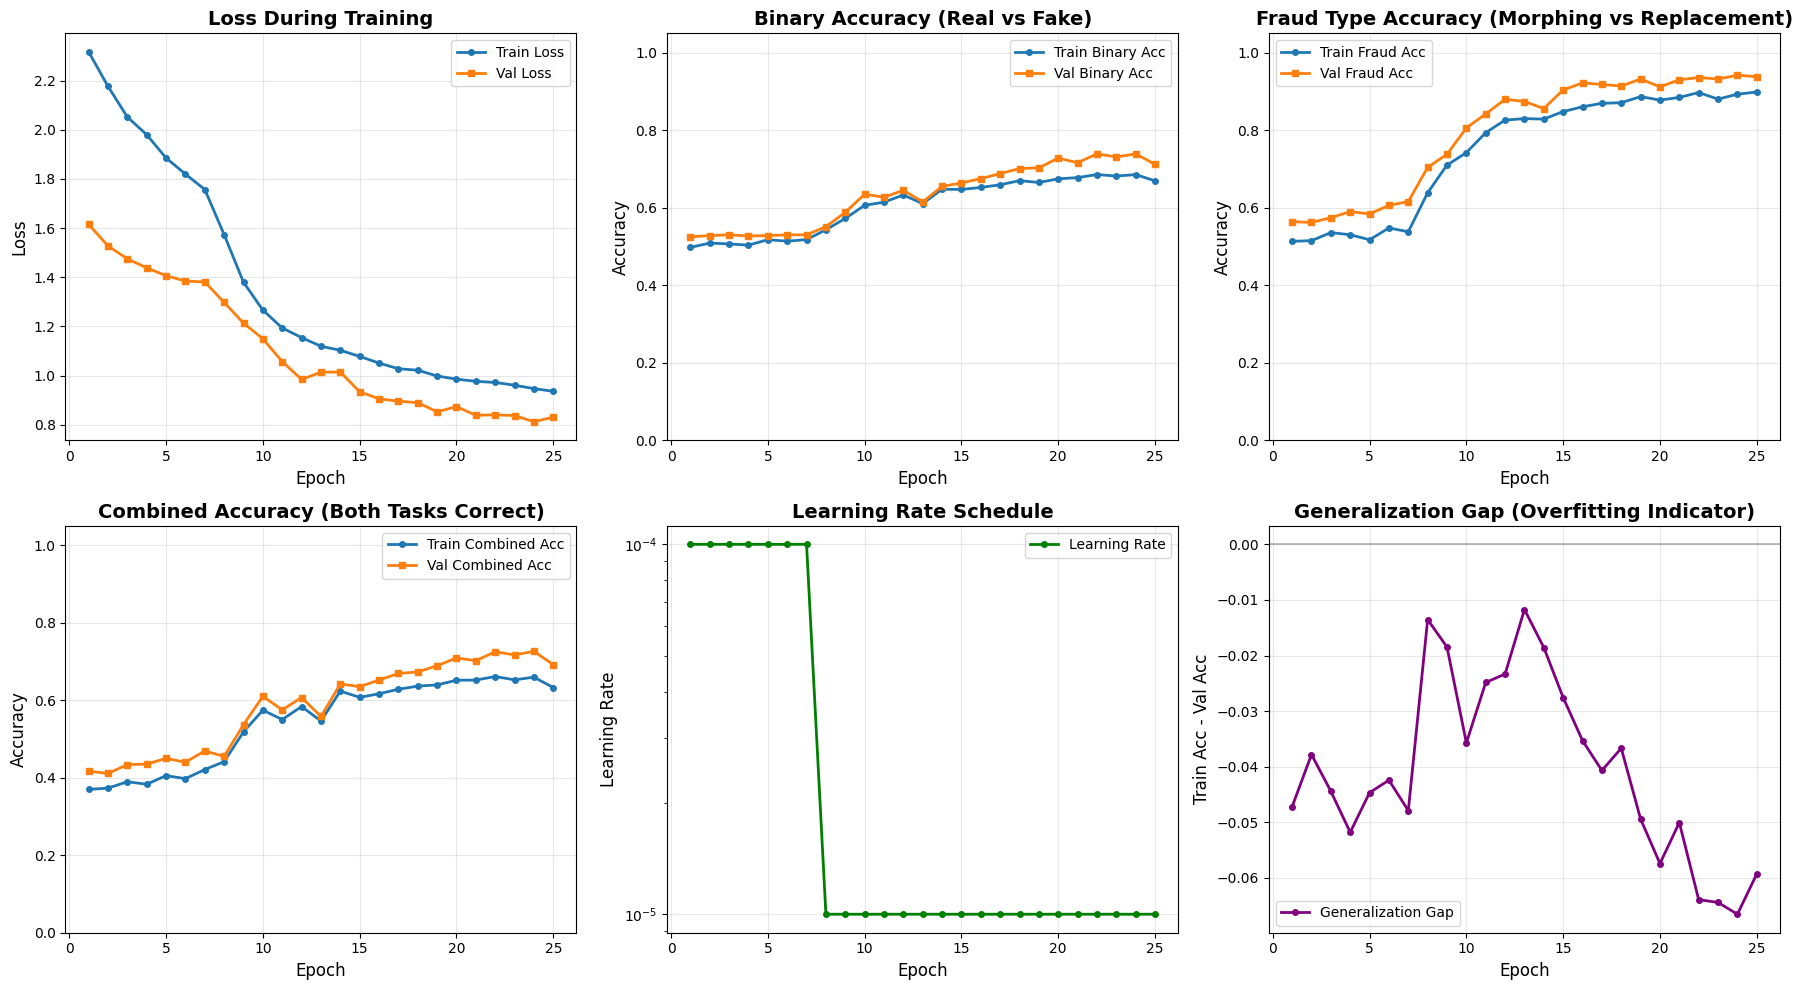


Confusion Matrices on Test Set


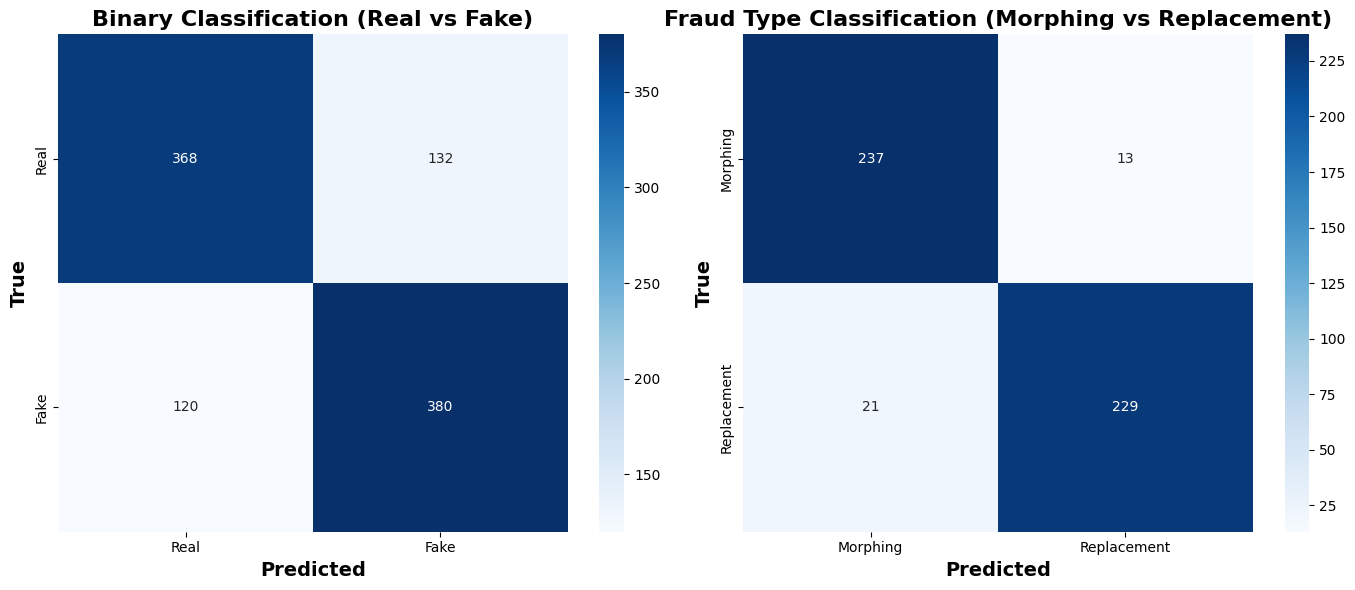


Classification Report - Binary Task
              precision    recall  f1-score   support

        Real       0.75      0.74      0.74       500
        Fake       0.74      0.76      0.75       500

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75      0.75      1000


Classification Report - Fraud Type Task
              precision    recall  f1-score   support

    Morphing       0.92      0.95      0.93       250
 Replacement       0.95      0.92      0.93       250

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500


Training Summary
Total Epochs Trained: 25
Best Train Binary Accuracy: 0.6856
Best Val Binary Accuracy: 0.7390
Best Train Fraud Type Accuracy: 0.8984
Best Val Fraud Type Accuracy: 0.9420
Best Val Combined Accuracy: 0.7250 (Epoch 22)
Final Test Binary Accuracy: 0.7480


In [12]:
# ============================================
# Training Graphs
# ============================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Graph 1: Loss (Train vs Val)
axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Graph 2: Binary Accuracy (Train vs Val)
axes[0, 1].plot(epochs, history['train_binary_acc'], label='Train Binary Acc', marker='o', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_binary_acc'], label='Val Binary Acc', marker='s', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Binary Accuracy (Real vs Fake)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1.05])

# Graph 3: Fraud Type Accuracy (Train vs Val)
axes[0, 2].plot(epochs, history['train_fraud_acc'], label='Train Fraud Acc', marker='o', linewidth=2, markersize=4)
axes[0, 2].plot(epochs, history['val_fraud_acc'], label='Val Fraud Acc', marker='s', linewidth=2, markersize=4)
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Accuracy', fontsize=12)
axes[0, 2].set_title('Fraud Type Accuracy (Morphing vs Replacement)', fontsize=14, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_ylim([0, 1.05])

# Graph 4: Combined Accuracy (Train vs Val)
axes[1, 0].plot(epochs, history['train_combined_acc'], label='Train Combined Acc', marker='o', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_combined_acc'], label='Val Combined Acc', marker='s', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Combined Accuracy (Both Tasks Correct)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

# Graph 5: Learning Rate Curve
axes[1, 1].plot(epochs, history['lr'], label='Learning Rate', marker='o', linewidth=2, markersize=4, color='green')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

# Graph 6: Generalization Gap (Train Combined Acc - Val Combined Acc)
gen_gap = [t - v for t, v in zip(history['train_combined_acc'], history['val_combined_acc'])]
axes[1, 2].plot(epochs, gen_gap, label='Generalization Gap', marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 2].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 2].set_xlabel('Epoch', fontsize=12)
axes[1, 2].set_ylabel('Train Acc - Val Acc', fontsize=12)
axes[1, 2].set_title('Generalization Gap (Overfitting Indicator)', fontsize=14, fontweight='bold')
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Confusion Matrices
# ============================================
print("\n" + "="*60)
print("Confusion Matrices on Test Set")
print("="*60)

# Collect predictions for confusion matrices
model.eval()
all_binary_preds = []
all_binary_labels = []
all_fraud_preds = []
all_fraud_labels = []

with torch.no_grad():
    for imgs, is_fake_labels, fraud_type_labels in test_loader:
        imgs = imgs.to(device)
        is_fake_labels = is_fake_labels.to(device)
        fraud_type_labels = fraud_type_labels.to(device)
        
        binary_outputs, fraud_type_outputs = model(imgs)
        
        binary_preds = binary_outputs.argmax(dim=1)
        all_binary_preds.extend(binary_preds.cpu().numpy())
        all_binary_labels.extend(is_fake_labels.cpu().numpy())
        
        # Fraud type predictions (only on fakes)
        fake_mask = (is_fake_labels == 1)
        if fake_mask.sum() > 0:
            fraud_preds = fraud_type_outputs[fake_mask].argmax(dim=1)
            all_fraud_preds.extend(fraud_preds.cpu().numpy())
            all_fraud_labels.extend(fraud_type_labels[fake_mask].cpu().numpy())

# Binary Confusion Matrix
binary_cm = confusion_matrix(all_binary_labels, all_binary_preds)
binary_labels = ['Real', 'Fake']

# Fraud Type Confusion Matrix
fraud_cm = confusion_matrix(all_fraud_labels, all_fraud_preds)
fraud_labels = ['Morphing', 'Replacement']

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Binary CM
sns.heatmap(binary_cm, annot=True, fmt="d", cmap="Blues", xticklabels=binary_labels, yticklabels=binary_labels, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True', fontsize=14, fontweight='bold')
axes[0].set_title('Binary Classification (Real vs Fake)', fontsize=16, fontweight='bold')

# Fraud Type CM
sns.heatmap(fraud_cm, annot=True, fmt="d", cmap="Blues", xticklabels=fraud_labels, yticklabels=fraud_labels, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True', fontsize=14, fontweight='bold')
axes[1].set_title('Fraud Type Classification (Morphing vs Replacement)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Print classification reports
print("\n" + "="*60)
print("Classification Report - Binary Task")
print("="*60)
print(classification_report(all_binary_labels, all_binary_preds, target_names=binary_labels))

print("\n" + "="*60)
print("Classification Report - Fraud Type Task")
print("="*60)
print(classification_report(all_fraud_labels, all_fraud_preds, target_names=fraud_labels))

# ============================================
# Training Summary
# ============================================
print("\n" + "="*60)
print("Training Summary")
print("="*60)
print(f"Total Epochs Trained: {len(history['train_binary_acc'])}")
print(f"Best Train Binary Accuracy: {max(history['train_binary_acc']):.4f}")
print(f"Best Val Binary Accuracy: {max(history['val_binary_acc']):.4f}")
print(f"Best Train Fraud Type Accuracy: {max(history['train_fraud_acc']):.4f}")
print(f"Best Val Fraud Type Accuracy: {max(history['val_fraud_acc']):.4f}")
print(f"Best Val Combined Accuracy: {best_val_combined_acc:.4f} (Epoch {best_epoch})")
print(f"Final Test Binary Accuracy: {test_metrics['binary_acc']:.4f}")
print(f"Final Test Fraud Type Accuracy: {test_metrics['fraud_acc']:.4f}")
print(f"Final Test Combined Accuracy: {test_metrics['combined_acc']:.4f}")


In [13]:
# Save model to the notebook directory
import pickle

notebook_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit"
model_path = os.path.join(notebook_dir, "vit_multi_task_forgery_9996.pth")

# Check if best_model_state exists
try:
    if 'best_model_state' in locals() or 'best_model_state' in globals():
        if best_model_state is not None:
            # Load best model state into model
            model.load_state_dict(best_model_state)
            print("✓ Loaded best model state (from early stopping) before saving")
            # Save best model
            torch.save(best_model_state, model_path)
            print(f"✓ Best model weights saved to: {model_path}")
            print(f"  (Best validation combined accuracy: {best_val_combined_acc:.4f} at epoch {best_epoch})")
        else:
            # No best model state, save current model
            torch.save(model.state_dict(), model_path)
            print(f"✓ Model weights saved to: {model_path}")
    else:
        # best_model_state variable doesn't exist, save current model
        torch.save(model.state_dict(), model_path)
        print(f"✓ Model weights saved to: {model_path}")
except NameError:
    # Variables don't exist, save current model
    torch.save(model.state_dict(), model_path)
    print(f"✓ Model weights saved to: {model_path}")

# Also save in project root for easy access
root_model_path = "/Users/roy-siftt/final-project/vit_multi_task_forgery_9996.pth"
try:
    if 'best_model_state' in locals() or 'best_model_state' in globals():
        if best_model_state is not None:
            torch.save(best_model_state, root_model_path)
        else:
            torch.save(model.state_dict(), root_model_path)
    else:
        torch.save(model.state_dict(), root_model_path)
    print(f"✓ Model also saved to: {root_model_path}")
except NameError:
    torch.save(model.state_dict(), root_model_path)
    print(f"✓ Model also saved to: {root_model_path}")

# Save label maps
binary_label_map = {0: "real", 1: "fake"}
fraud_type_label_map = {0: "face_morphing", 1: "face_replacement"}

label_maps = {
    'binary': binary_label_map,
    'fraud_type': fraud_type_label_map
}

label_map_path = os.path.join(notebook_dir, "vit_multi_task_label_maps.pkl")
with open(label_map_path, "wb") as f:
    pickle.dump(label_maps, f)
print(f"✓ Label maps saved to: {label_map_path}")

# Verify file was created
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path) / (1024 * 1024)  # Size in MB
    print(f"✓ File verified: {model_path} ({file_size:.2f} MB)")
else:
    print(f"⚠️  Warning: File not found at {model_path}")

print("\n" + "="*60)
print("Label Mappings:")
print("="*60)
print("Binary Task:")
for idx, name in binary_label_map.items():
    print(f"  {idx} → {name}")
print("\nFraud Type Task:")
for idx, name in fraud_type_label_map.items():
    print(f"  {idx} → {name}")


✓ Loaded best model state (from early stopping) before saving
✓ Best model weights saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/vit_multi_task_forgery_9996.pth
  (Best validation combined accuracy: 0.7250 at epoch 22)
✓ Model also saved to: /Users/roy-siftt/final-project/vit_multi_task_forgery_9996.pth
✓ Label maps saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/vit_multi_task_label_maps.pkl
✓ File verified: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/vit_multi_task_forgery_9996.pth (21.14 MB)

Label Mappings:
Binary Task:
  0 → real
  1 → fake

Fraud Type Task:
  0 → face_morphing
  1 → face_replacement


## Test Model on Custom Image

Test the trained model on a single image by providing its path. This allows you to test the model on images outside the dataset.



🔍 Testing model on: /Users/roy-siftt/final-project/datasets/idnet/AZ/positive/generated.photos_v3_0999206.png


/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_73020/2062871716.py:128: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_73020/2062871716.py:128: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_73020/2062871716.py:128: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mo

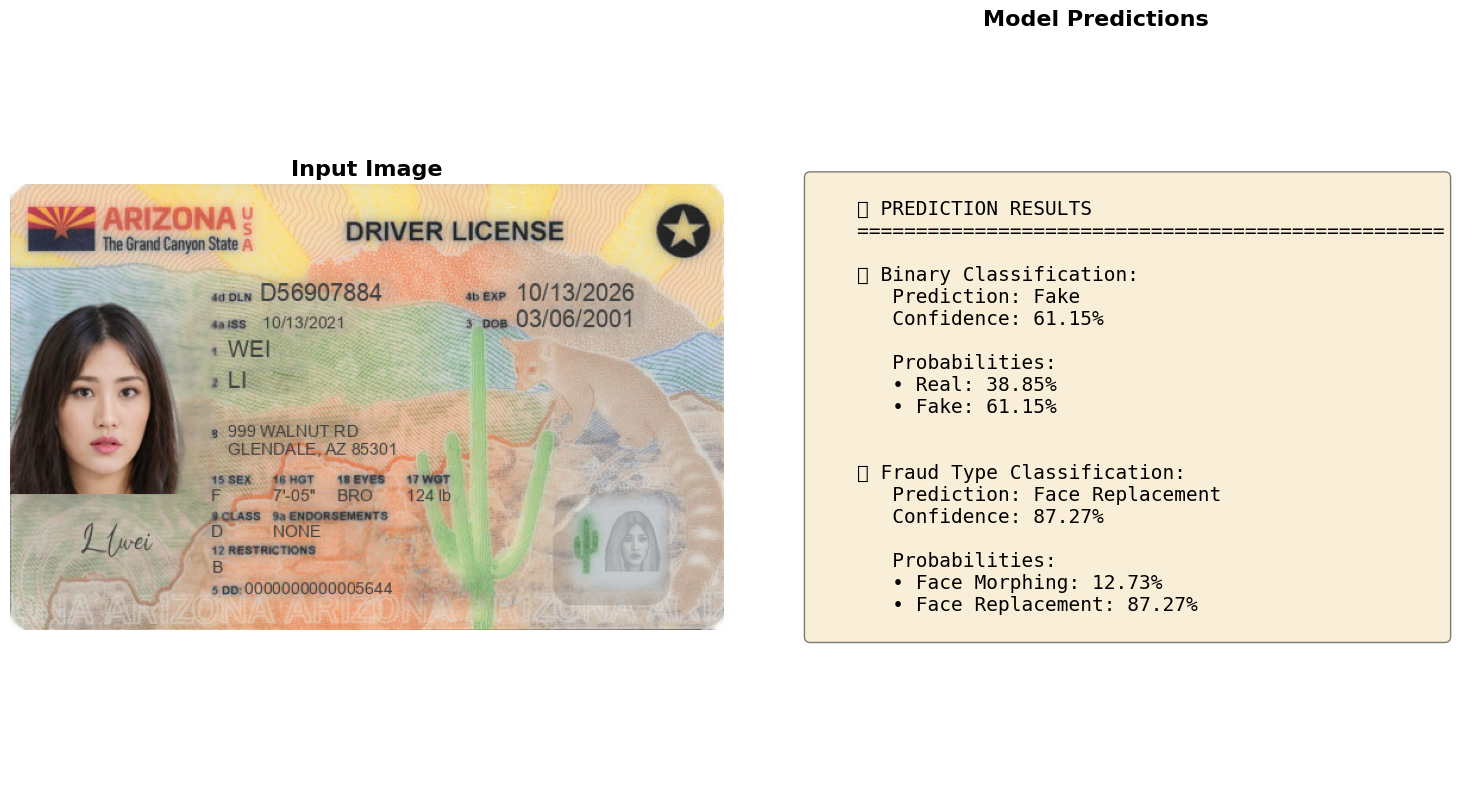


DETAILED PREDICTION RESULTS

📸 Image: /Users/roy-siftt/final-project/datasets/idnet/AZ/positive/generated.photos_v3_0999206.png

🔍 Binary Classification:
   Prediction: Fake
   Confidence: 61.15%
   Probabilities:
        Real: 38.85%
      ✓ Fake: 61.15%

🎭 Fraud Type Classification:
   Prediction: Face Replacement
   Confidence: 87.27%
   Probabilities:
        Face Morphing: 12.73%
      ✓ Face Replacement: 87.27%


In [14]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

def predict_image(image_path, model, device, transform=None):
    """
    Predict on a single image and return both binary and fraud type predictions.
    
    Args:
        image_path: Path to the image file
        model: Trained model
        device: Device to run inference on
        transform: Transform to apply (if None, uses default val/test transform)
    
    Returns:
        Dictionary with predictions and probabilities
    """
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    # Use default transform if not provided
    if transform is None:
        transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize(
                mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)
            ),
            ToTensorV2(),
        ])
    
    # Apply transform
    transformed = transform(image=img_np)
    img_tensor = transformed['image'].unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        binary_outputs, fraud_type_outputs = model(img_tensor)
        
        # Get binary predictions
        binary_probs = F.softmax(binary_outputs, dim=1)
        binary_pred = torch.argmax(binary_outputs, dim=1).item()
        binary_confidence = binary_probs[0][binary_pred].item()
        
        # Get fraud type predictions
        fraud_type_probs = F.softmax(fraud_type_outputs, dim=1)
        fraud_type_pred = torch.argmax(fraud_type_outputs, dim=1).item()
        fraud_type_confidence = fraud_type_probs[0][fraud_type_pred].item()
        
        # Label mappings
        binary_labels = {0: "Real", 1: "Fake"}
        fraud_type_labels = {0: "Face Morphing", 1: "Face Replacement"}
        
        result = {
            'binary_prediction': binary_labels[binary_pred],
            'binary_confidence': binary_confidence,
            'binary_probs': {
                'Real': binary_probs[0][0].item(),
                'Fake': binary_probs[0][1].item()
            },
            'fraud_type_prediction': fraud_type_labels[fraud_type_pred] if binary_pred == 1 else "N/A (Real image)",
            'fraud_type_confidence': fraud_type_confidence if binary_pred == 1 else None,
            'fraud_type_probs': {
                'Face Morphing': fraud_type_probs[0][0].item(),
                'Face Replacement': fraud_type_probs[0][1].item()
            } if binary_pred == 1 else None,
            'original_image': img
        }
        
        return result

def visualize_prediction(image_path, result):
    """
    Visualize the image with predictions.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Left: Original image
    axes[0].imshow(result['original_image'])
    axes[0].axis('off')
    axes[0].set_title('Input Image', fontsize=16, fontweight='bold')
    
    # Right: Prediction results
    axes[1].axis('off')
    
    # Create text summary
    text = f"""
    📊 PREDICTION RESULTS
    {'='*50}
    
    🔍 Binary Classification:
       Prediction: {result['binary_prediction']}
       Confidence: {result['binary_confidence']*100:.2f}%
       
       Probabilities:
       • Real: {result['binary_probs']['Real']*100:.2f}%
       • Fake: {result['binary_probs']['Fake']*100:.2f}%
    
    """
    
    if result['binary_prediction'] == "Fake":
        text += f"""
    🎭 Fraud Type Classification:
       Prediction: {result['fraud_type_prediction']}
       Confidence: {result['fraud_type_confidence']*100:.2f}%
       
       Probabilities:
       • Face Morphing: {result['fraud_type_probs']['Face Morphing']*100:.2f}%
       • Face Replacement: {result['fraud_type_probs']['Face Replacement']*100:.2f}%
        """
    else:
        text += f"""
    ℹ️  Fraud Type: {result['fraud_type_prediction']}
       (Only applicable for fake images)
        """
    
    axes[1].text(0.1, 0.5, text, fontsize=14, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.5))
    axes[1].set_title('Model Predictions', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print("\n" + "="*60)
    print("DETAILED PREDICTION RESULTS")
    print("="*60)
    print(f"\n📸 Image: {image_path}")
    print(f"\n🔍 Binary Classification:")
    print(f"   Prediction: {result['binary_prediction']}")
    print(f"   Confidence: {result['binary_confidence']*100:.2f}%")
    print(f"   Probabilities:")
    for label, prob in result['binary_probs'].items():
        marker = "✓" if label == result['binary_prediction'] else " "
        print(f"      {marker} {label}: {prob*100:.2f}%")
    
    if result['binary_prediction'] == "Fake":
        print(f"\n🎭 Fraud Type Classification:")
        print(f"   Prediction: {result['fraud_type_prediction']}")
        print(f"   Confidence: {result['fraud_type_confidence']*100:.2f}%")
        print(f"   Probabilities:")
        for label, prob in result['fraud_type_probs'].items():
            marker = "✓" if label == result['fraud_type_prediction'] else " "
            print(f"      {marker} {label}: {prob*100:.2f}%")
    else:
        print(f"\nℹ️  Fraud Type: N/A (Image is Real)")
    
    print("="*60)

# ============================================
# Test on a single image
# ============================================
# Change this path to test on your own image
IMAGE_PATH = "/Users/roy-siftt/final-project/datasets/idnet/AZ/positive/generated.photos_v3_0999206.png"
# Make sure model is loaded (if not already loaded from training)
if 'model' not in locals() or model is None:
    print("Loading model...")
    notebook_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit"
    model_path = os.path.join(notebook_dir, "vit_multi_task_forgery_9996.pth")
    
    # Recreate model
    model = ViTMultiTaskClassifier(num_binary_classes=2, num_fraud_classes=2, pretrained=True, dropout=0.25).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("✓ Model loaded successfully!")

# Check if image path is provided
if IMAGE_PATH != "/path/to/your/image.png" and os.path.exists(IMAGE_PATH):
    print(f"\n🔍 Testing model on: {IMAGE_PATH}")
    result = predict_image(IMAGE_PATH, model, device)
    visualize_prediction(IMAGE_PATH, result)
else:
    print("⚠️  Please set IMAGE_PATH to a valid image path")
    print("\nExample usage:")
    print('  IMAGE_PATH = "datasets/test/your_image.jpg"')
    print('  result = predict_image(IMAGE_PATH, model, device)')
    print('  visualize_prediction(IMAGE_PATH, result)')


## Comprehensive Model Evaluation on Random Samples

Test the model on 100 randomly selected images from the original IDNet dataset (not in training set) with known labels. This allows us to evaluate the model's real-world performance on unseen data.


In [15]:
import json
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Load test samples
test_samples_path = "notebooks/drivers_license_forgery/vit/test_samples.json"
with open(test_samples_path, 'r') as f:
    test_samples = json.load(f)

print(f"✓ Loaded {len(test_samples)} test samples")
print(f"  Real: {sum(1 for s in test_samples if s['is_fake'] == 0)}")
print(f"  Fake: {sum(1 for s in test_samples if s['is_fake'] == 1)}")
print(f"  Face Morphing: {sum(1 for s in test_samples if s['fraud_type'] == 'face_morphing')}")
print(f"  Face Replacement: {sum(1 for s in test_samples if s['fraud_type'] == 'face_replacement')}")

# Make sure model is loaded
if 'model' not in locals() or model is None:
    print("\nLoading model...")
    notebook_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit"
    model_path = os.path.join(notebook_dir, "vit_multi_task_forgery_9996.pth")
    model = ViTMultiTaskClassifier(num_binary_classes=2, num_fraud_classes=2, pretrained=True, dropout=0.25).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("✓ Model loaded successfully!")

# Evaluate on all samples
results = []
binary_predictions = []
binary_expected = []
fraud_predictions = []
fraud_expected = []

print("\n" + "="*60)
print("Evaluating Model on Test Samples")
print("="*60)

for sample in tqdm(test_samples, desc="Processing images"):
    image_path = sample['path']
    
    # Check if file exists
    if not os.path.exists(image_path):
        print(f"⚠️  Warning: File not found: {image_path}")
        continue
    
    try:
        # Get prediction
        result = predict_image(image_path, model, device)
        
        # Store results
        binary_pred = result['binary_prediction']
        fraud_pred = result['fraud_type_prediction'] if result['binary_prediction'] == 'Fake' else 'N/A'
        
        binary_predictions.append(binary_pred)
        binary_expected.append(sample['expected_binary'])
        
        # Only compare fraud type for fake images
        if sample['is_fake'] == 1:
            fraud_predictions.append(fraud_pred)
            fraud_expected.append(sample['expected_fraud_type'])
        
        # Determine if correct
        binary_correct = (binary_pred == sample['expected_binary'])
        fraud_correct = None
        if sample['is_fake'] == 1:
            fraud_correct = (fraud_pred == sample['expected_fraud_type'])
        
        results.append({
            'path': image_path,
            'country': sample['country'],
            'expected_binary': sample['expected_binary'],
            'predicted_binary': binary_pred,
            'binary_confidence': result['binary_confidence'],
            'binary_correct': binary_correct,
            'expected_fraud_type': sample['expected_fraud_type'],
            'predicted_fraud_type': fraud_pred,
            'fraud_confidence': result['fraud_type_confidence'] if fraud_pred != 'N/A' else None,
            'fraud_correct': fraud_correct
        })
    except Exception as e:
        print(f"❌ Error processing {image_path}: {e}")
        continue

print(f"\n✓ Processed {len(results)} images successfully")

# Calculate metrics
df_results = pd.DataFrame(results)

# Binary classification metrics
binary_acc = accuracy_score(binary_expected, binary_predictions)
print(f"\n{'='*60}")
print("BINARY CLASSIFICATION RESULTS")
print(f"{'='*60}")
print(f"Accuracy: {binary_acc:.4f} ({binary_acc*100:.2f}%)")
print(f"\nConfusion Matrix:")
binary_cm = confusion_matrix(binary_expected, binary_predictions, labels=['Real', 'Fake'])
print(binary_cm)
print(f"\nClassification Report:")
print(classification_report(binary_expected, binary_predictions, labels=['Real', 'Fake'], target_names=['Real', 'Fake']))

# Fraud type classification metrics (only on fake images)
if len(fraud_predictions) > 0:
    fraud_acc = accuracy_score(fraud_expected, fraud_predictions)
    print(f"\n{'='*60}")
    print("FRAUD TYPE CLASSIFICATION RESULTS (Fake images only)")
    print(f"{'='*60}")
    print(f"Accuracy: {fraud_acc:.4f} ({fraud_acc*100:.2f}%)")
    print(f"\nConfusion Matrix:")
    fraud_cm = confusion_matrix(fraud_expected, fraud_predictions, labels=['Face Morphing', 'Face Replacement'])
    print(fraud_cm)
    print(f"\nClassification Report:")
    print(classification_report(fraud_expected, fraud_predictions, labels=['Face Morphing', 'Face Replacement'], 
                              target_names=['Face Morphing', 'Face Replacement']))

# Combined accuracy (both tasks correct)
combined_correct = 0
combined_total = 0
for r in results:
    combined_total += 1
    if r['binary_correct']:
        if r['expected_binary'] == 'Real':
            combined_correct += 1
        elif r['fraud_correct']:
            combined_correct += 1

combined_acc = combined_correct / combined_total if combined_total > 0 else 0
print(f"\n{'='*60}")
print("COMBINED ACCURACY (Both tasks correct)")
print(f"{'='*60}")
print(f"Accuracy: {combined_acc:.4f} ({combined_acc*100:.2f}%)")
print(f"Correct: {combined_correct}/{combined_total}")

# Breakdown by country
print(f"\n{'='*60}")
print("BREAKDOWN BY COUNTRY")
print(f"{'='*60}")
for country in ['WV', 'DC', 'AZ']:
    country_results = [r for r in results if r['country'] == country]
    if len(country_results) > 0:
        country_binary_acc = sum(1 for r in country_results if r['binary_correct']) / len(country_results)
        country_fraud_results = [r for r in country_results if r['expected_binary'] == 'Fake']
        if len(country_fraud_results) > 0:
            country_fraud_acc = sum(1 for r in country_fraud_results if r['fraud_correct']) / len(country_fraud_results)
        else:
            country_fraud_acc = None
        
        print(f"\n{country}:")
        print(f"  Binary Accuracy: {country_binary_acc:.4f} ({country_binary_acc*100:.2f}%)")
        if country_fraud_acc is not None:
            print(f"  Fraud Type Accuracy: {country_fraud_acc:.4f} ({country_fraud_acc*100:.2f}%)")
        print(f"  Total samples: {len(country_results)}")

# Show some examples of correct and incorrect predictions
print(f"\n{'='*60}")
print("SAMPLE CORRECT PREDICTIONS")
print(f"{'='*60}")
correct_samples = [r for r in results if r['binary_correct'] and (r['fraud_correct'] if r['expected_binary'] == 'Fake' else True)]
for i, sample in enumerate(correct_samples[:5]):
    print(f"\n{i+1}. {os.path.basename(sample['path'])}")
    print(f"   Expected: {sample['expected_binary']} ({sample['expected_fraud_type']})")
    print(f"   Predicted: {sample['predicted_binary']} ({sample['predicted_fraud_type']})")
    fraud_conf_str = f"{sample['fraud_confidence']*100:.1f}%" if sample['fraud_confidence'] is not None else "N/A"
    print(f"   Confidence: Binary={sample['binary_confidence']*100:.1f}%, Fraud={fraud_conf_str}")

print(f"\n{'='*60}")
print("SAMPLE INCORRECT PREDICTIONS")
print(f"{'='*60}")
incorrect_samples = [r for r in results if not r['binary_correct'] or (r['expected_binary'] == 'Fake' and not r['fraud_correct'])]
for i, sample in enumerate(incorrect_samples[:5]):
    print(f"\n{i+1}. {os.path.basename(sample['path'])}")
    print(f"   Expected: {sample['expected_binary']} ({sample['expected_fraud_type']})")
    print(f"   Predicted: {sample['predicted_binary']} ({sample['predicted_fraud_type']})")
    fraud_conf_str = f"{sample['fraud_confidence']*100:.1f}%" if sample['fraud_confidence'] is not None else "N/A"
    print(f"   Confidence: Binary={sample['binary_confidence']*100:.1f}%, Fraud={fraud_conf_str}")

# Save detailed results
results_df = pd.DataFrame(results)
results_df.to_csv('notebooks/drivers_license_forgery/vit/evaluation_results.csv', index=False)
print(f"\n✓ Detailed results saved to: notebooks/drivers_license_forgery/vit/evaluation_results.csv")


✓ Loaded 999 test samples
  Real: 333
  Fake: 666
  Face Morphing: 333
  Face Replacement: 333

Evaluating Model on Test Samples


Processing images: 100%|██████████| 999/999 [00:28<00:00, 35.45it/s]


✓ Processed 999 images successfully

BINARY CLASSIFICATION RESULTS
Accuracy: 0.7057 (70.57%)

Confusion Matrix:
[[245  88]
 [206 460]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.54      0.74      0.62       333
        Fake       0.84      0.69      0.76       666

    accuracy                           0.71       999
   macro avg       0.69      0.71      0.69       999
weighted avg       0.74      0.71      0.71       999


FRAUD TYPE CLASSIFICATION RESULTS (Fake images only)
Accuracy: 0.6532 (65.32%)

Confusion Matrix:
[[149  22]
 [  3 286]]

Classification Report:
                  precision    recall  f1-score   support

   Face Morphing       0.98      0.45      0.61       333
Face Replacement       0.93      0.86      0.89       333

       micro avg       0.95      0.65      0.77       666
       macro avg       0.95      0.65      0.75       666
    weighted avg       0.95      0.65      0.75       666


COMBINED ACCURA

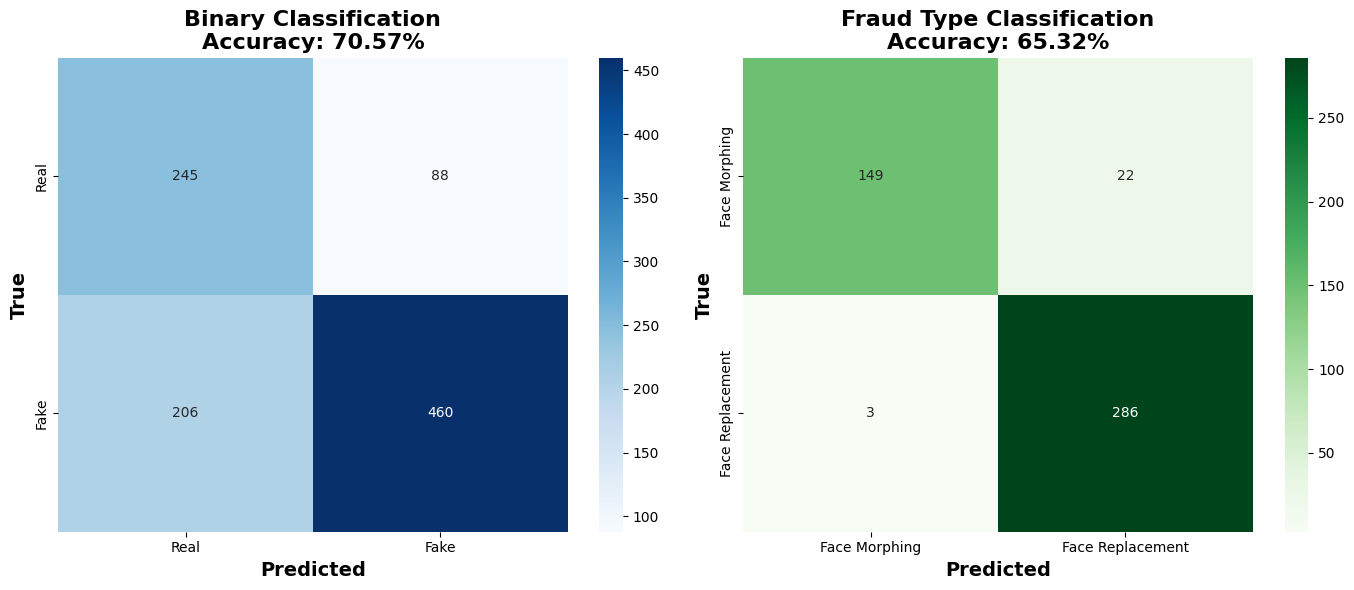


SUMMARY STATISTICS
Total Images Tested: 999
Binary Classification Accuracy: 0.7057 (70.57%)
Fraud Type Classification Accuracy: 0.6532 (65.32%)
Combined Accuracy (Both correct): 0.6807 (68.07%)

Binary Classification Breakdown:
  Real images: 333
  Fake images: 666
  Correct Real predictions: 245
  Correct Fake predictions: 460

Fraud Type Classification Breakdown:
  Face Morphing: 333
  Face Replacement: 333
  Correct Morphing predictions: 149
  Correct Replacement predictions: 286


In [16]:
# Visualize confusion matrices
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Binary Confusion Matrix
sns.heatmap(binary_cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True', fontsize=14, fontweight='bold')
axes[0].set_title(f'Binary Classification\nAccuracy: {binary_acc*100:.2f}%', fontsize=16, fontweight='bold')

# Fraud Type Confusion Matrix
if len(fraud_predictions) > 0:
    sns.heatmap(fraud_cm, annot=True, fmt="d", cmap="Greens", 
                xticklabels=['Face Morphing', 'Face Replacement'], 
                yticklabels=['Face Morphing', 'Face Replacement'], ax=axes[1])
    axes[1].set_xlabel('Predicted', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True', fontsize=14, fontweight='bold')
    axes[1].set_title(f'Fraud Type Classification\nAccuracy: {fraud_acc*100:.2f}%', fontsize=16, fontweight='bold')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'No fake images\nin test set', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*60}")
print("SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"Total Images Tested: {len(results)}")
print(f"Binary Classification Accuracy: {binary_acc:.4f} ({binary_acc*100:.2f}%)")
if len(fraud_predictions) > 0:
    print(f"Fraud Type Classification Accuracy: {fraud_acc:.4f} ({fraud_acc*100:.2f}%)")
print(f"Combined Accuracy (Both correct): {combined_acc:.4f} ({combined_acc*100:.2f}%)")
print(f"\nBinary Classification Breakdown:")
print(f"  Real images: {sum(1 for r in results if r['expected_binary'] == 'Real')}")
print(f"  Fake images: {sum(1 for r in results if r['expected_binary'] == 'Fake')}")
print(f"  Correct Real predictions: {sum(1 for r in results if r['expected_binary'] == 'Real' and r['binary_correct'])}")
print(f"  Correct Fake predictions: {sum(1 for r in results if r['expected_binary'] == 'Fake' and r['binary_correct'])}")
if len(fraud_predictions) > 0:
    print(f"\nFraud Type Classification Breakdown:")
    print(f"  Face Morphing: {sum(1 for r in results if r['expected_fraud_type'] == 'Face Morphing')}")
    print(f"  Face Replacement: {sum(1 for r in results if r['expected_fraud_type'] == 'Face Replacement')}")
    print(f"  Correct Morphing predictions: {sum(1 for r in results if r['expected_fraud_type'] == 'Face Morphing' and r['fraud_correct'])}")
    print(f"  Correct Replacement predictions: {sum(1 for r in results if r['expected_fraud_type'] == 'Face Replacement' and r['fraud_correct'])}")


## Data Overlap Check

Check for overlap between test samples and training dataset to ensure test samples are truly unseen.


In [17]:
# Check for data overlap between test samples and training dataset
import json
import pandas as pd
import os

# Load test samples
test_samples_path = "notebooks/drivers_license_forgery/vit/test_samples.json"
with open(test_samples_path, 'r') as f:
    test_samples = json.load(f)

# Load training dataset
train_df = pd.read_csv('notebooks/drivers_license_forgery/vit/data/dataset.csv')

# Extract original filenames from test samples
test_original_filenames = set()
test_samples_info = {}
for sample in test_samples:
    path = sample['path']
    filename = os.path.basename(path)
    test_original_filenames.add(filename)
    test_samples_info[filename] = sample

# Extract original filenames from training dataset
train_original_filenames = set(train_df['original_filename'].dropna().unique())

# Check overlap
overlap = test_original_filenames & train_original_filenames

print("="*60)
print("DATA OVERLAP CHECK")
print("="*60)
print(f"\nTest samples: {len(test_original_filenames)} unique filenames")
print(f"Training dataset: {len(train_original_filenames)} unique filenames")
print(f"Overlap: {len(overlap)} filenames ({len(overlap)/len(test_original_filenames)*100:.1f}%)")

if len(overlap) > 0:
    print(f"\n⚠️  WARNING: {len(overlap)} test samples were also in training data!")
    print("\nOverlapping files:")
    for i, filename in enumerate(list(overlap)[:10], 1):
        sample_info = test_samples_info[filename]
        print(f"  {i}. {filename}")
        print(f"     Path: {sample_info['path']}")
        print(f"     Country: {sample_info['country']}, Type: {sample_info['expected_binary']} ({sample_info['expected_fraud_type']})")
    
    if len(overlap) > 10:
        print(f"  ... and {len(overlap) - 10} more")
    
    # Check how many of the overlapping samples were predicted correctly
    # Note: 'results' should be available from the previous evaluation cell
    try:
        if 'results' in globals() and len(results) > 0:
            overlap_results = [r for r in results if os.path.basename(r['path']) in overlap]
            if len(overlap_results) > 0:
                overlap_correct = sum(1 for r in overlap_results if r['binary_correct'] and 
                                     (r['fraud_correct'] if r['expected_binary'] == 'Fake' else True))
                print(f"\n📊 Performance on overlapping samples:")
                print(f"   Total overlapping: {len(overlap_results)}")
                print(f"   Correct: {overlap_correct} ({overlap_correct/len(overlap_results)*100:.1f}%)")
                
                # Compare with non-overlapping
                non_overlap_results = [r for r in results if os.path.basename(r['path']) not in overlap]
                if len(non_overlap_results) > 0:
                    non_overlap_correct = sum(1 for r in non_overlap_results if r['binary_correct'] and 
                                             (r['fraud_correct'] if r['expected_binary'] == 'Fake' else True))
                    print(f"\n📊 Performance on non-overlapping samples:")
                    print(f"   Total non-overlapping: {len(non_overlap_results)}")
                    print(f"   Correct: {non_overlap_correct} ({non_overlap_correct/len(non_overlap_results)*100:.1f}%)")
                    
                    print(f"\n📈 Difference:")
                    print(f"   Overlapping accuracy: {overlap_correct/len(overlap_results)*100:.1f}%")
                    print(f"   Non-overlapping accuracy: {non_overlap_correct/len(non_overlap_results)*100:.1f}%")
                    print(f"   Gap: {abs(overlap_correct/len(overlap_results) - non_overlap_correct/len(non_overlap_results))*100:.1f}%")
        else:
            print("\n⚠️  Note: 'results' variable not found. Run the evaluation cell first to see performance comparison.")
    except NameError:
        print("\n⚠️  Note: 'results' variable not found. Run the evaluation cell first to see performance comparison.")
else:
    print("\n✅ No overlap detected - test samples are truly unseen!")
    print("   The performance gap is likely due to:")
    print("   - Domain shift (different image characteristics)")
    print("   - Model overfitting to training distribution")
    print("   - Different difficulty level of test samples")

print("="*60)


DATA OVERLAP CHECK

Test samples: 911 unique filenames
Training dataset: 1666 unique filenames
Overlap: 0 filenames (0.0%)

✅ No overlap detected - test samples are truly unseen!
   The performance gap is likely due to:
   - Domain shift (different image characteristics)
   - Model overfitting to training distribution
   - Different difficulty level of test samples
